# Dataset metrics

How hard each registered dataset is, before any model is trained on it. The
notebook only **reads** what `gnn-bench difficulty` cached under
`results/<dataset>/difficulty.json`, so it shows every dataset that has been
measured and nothing else. To add one, or to re-measure with other settings:

```
gnn-bench difficulty <key> --systems 60 --history 3 --count 20 --max-frames 28 [--manifest ""]
```

`--manifest ""` means every system on disk; the Kremer-Grest sets use `clean`.
Rows are only comparable across datasets when `history` and `count` agree --
the settings table below says what each file was measured with.

**How to read it.** `floor_model` first: the best *linear* predictor of the
one-step target, fed what a model is actually fed. Then `r2_ceiling` beside it,
the best R² *any* predictor can reach given the float32 rounding in the stored
positions. A floor only means something relative to its ceiling.

Optional last section (off by default, reads trajectory files): the per-bond
stiffness profile of the harmonic sets.

In [1]:
import json
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore", message="IProgress not found")          # tqdm, pulled in on import
warnings.filterwarnings("ignore", message=".*torch.jit.script.*")        # torch_geometric on Python 3.14

from gnn_physics_benchmark.data import registry
from gnn_physics_benchmark.results import cache

RESULTS = cache.results_root()  # results/ beside the repository, wherever the notebook runs from

pd.set_option("display.width", 200, "display.max_columns", 40, "display.precision", 4)

## Load the cached measurements

One row per measured system. The display order is fixed so the colour and
marker of a dataset never change between plots -- or between runs of this
notebook when a new dataset is added (new keys go to the end).

In [2]:
PREFERRED_ORDER = ["node_optimized", "stiff_optimized", "noisy_dump200", "dePablo_random", "cold_wca_fixyz_n1024"]

measured = {}
for path in sorted(RESULTS.glob("*/difficulty.json")):
    measured[path.parent.name] = json.loads(path.read_text())
if not measured:
    raise FileNotFoundError(f"no difficulty.json under {RESULTS}; run `gnn-bench difficulty <key>` first.")

ORDER = [k for k in PREFERRED_ORDER if k in measured] + sorted(k for k in measured if k not in PREFERRED_ORDER)

rows = pd.DataFrame(
    [{"dataset": key, **row} for key in ORDER for row in measured[key]["rows"]]
)
rows["dataset"] = pd.Categorical(rows["dataset"], categories=ORDER, ordered=True)

settings = pd.DataFrame(
    [
        {
            "dataset": key,
            "systems measured": measured[key]["systems"],
            "systems on disk": len(registry.get(key).systems()) if key in registry.DATASETS else None,
            "manifest": measured[key]["manifest"] or "(all)",
            "history": measured[key]["history"],
            "count": measured[key]["count"],
            "dim": int(rows.loc[rows.dataset == key, "dim"].iloc[0]),
            "median nodes": int(rows.loc[rows.dataset == key, "nodes"].median()),
        }
        for key in ORDER
    ]
).set_index("dataset")
if settings[["history", "count"]].nunique().max() > 1:
    print("WARNING: datasets were measured with different history/count; rows are not comparable across them.")
settings

,systems measured,systems on disk,manifest,history,count,dim,median nodes
dataset,,,,,,,
node_optimized,60,1998,(all),3,20,2,148
stiff_optimized,60,1085,(all),3,20,2,244
noisy_dump200,60,401,(all),3,20,2,93
cold_wca_fixyz_n1024,60,1024,clean,3,20,3,396


### Colours and markers

One colour per dataset, assigned in fixed order. The first four slots were
checked for colour-blind separation across *every* pair, since these plots put
all datasets on one set of axes. Every dataset also has its own marker shape, so
colour is never the only cue -- which matters for the aqua slot, as it is below
3:1 contrast on white.

In [3]:
SLOTS = ["#2a78d6", "#eb6834", "#1baf7a", "#4a3aa7",   # validated all-pairs set
         "#008300", "#e34948", "#eda100", "#e87ba4"]   # beyond four: rely on the markers
MARKERS = ["o", "s", "^", "D", "v", "P", "X", "*"]
COLOR = {key: SLOTS[i % len(SLOTS)] for i, key in enumerate(ORDER)}
MARKER = {key: MARKERS[i % len(MARKERS)] for i, key in enumerate(ORDER)}

INK, MUTED, GRID = "#0b0b0b", "#52514e", "#e4e3df"
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": MUTED, "axes.labelcolor": INK, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8, "axes.axisbelow": True,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 11, "axes.titleweight": "bold", "axes.labelsize": 10,
    "xtick.labelsize": 9, "ytick.labelsize": 9, "legend.fontsize": 9, "legend.frameon": False,
    "figure.dpi": 110,
})

def legend_handles():
    return [plt.Line2D([], [], ls="", marker=MARKER[k], ms=7, mfc=COLOR[k], mec="white", mew=0.8, label=k) for k in ORDER]

## Metric glossary

Grouped by what each one tells you. Floors and ceilings are R² values, so higher
is easier. The position values are in the simulation's length units.

In [4]:
GROUPS = {
    "Linear floors -- how much a linear model already explains": {
        "floor_model": "the floor matched to what a model is fed (residual velocity; box motion removed from x only in 2D, from every axis in 3D). Read this first",
        "floor_kinematic": "also given the box at the *predicted* frame, which no model sees: describes the data rather than the task",
        "floor_affine": "the box motion alone",
        "floor_velocity": "residual velocity with box motion removed from every axis",
        "floor_velocity_x": "residual velocity with box motion removed from the driven axis only",
        "floor_velocity_total": "total (not residual) velocity",
    },
    "Ceiling -- how much of the target is signal at all": {
        "r2_ceiling": "best R² any predictor can reach, given the float32 rounding in the stored positions",
        "noise_over_signal": "RMS rounding noise in the target over the target RMS",
        "floor_share_of_ceiling": "floor_model / r2_ceiling: how much of the reachable signal a linear model already takes",
    },
    "Motion scales -- how far things move per step": {
        "target_rms": "RMS of the one-step target (second difference of positions)",
        "frozen_position_rms": "one-step position error of predicting that nothing moves",
        "velocity_position_rms": "the same error for the velocity-floor predictor",
        "drift_over_windows": "RMS node displacement over all the frames training reads",
    },
    "Dynamics character": {
        "affine_target_share": "share of the target's second moment that the box motion accounts for",
        "mean_persistence": "mean cosine between consecutive velocities: near 1 means smooth, nearly straight motion",
        "affine_share": "share of the velocity that is affine box motion",
        "alpha_over_speed": "mean velocity change per step over mean speed: higher means more complex dynamics",
    },
}
LOG_SCALE = {"target_rms", "frozen_position_rms", "velocity_position_rms", "drift_over_windows",
             "noise_over_signal", "alpha_over_speed"}
METRICS = [m for group in GROUPS.values() for m in group]

pd.DataFrame(
    [(group.split(" -- ")[0], metric, text) for group, metrics in GROUPS.items() for metric, text in metrics.items()],
    columns=["group", "metric", "meaning"],
).set_index(["group", "metric"]).style.set_properties(**{"text-align": "left", "white-space": "normal"})

## Summary tables

Medians over systems, then the 10th / 50th / 90th percentiles of the headline
numbers -- a median alone hides how uneven an ensemble is.

In [5]:
medians = rows.groupby("dataset", observed=True)[METRICS].median().T
medians.index.name = "median of"
medians.style.format("{:.4g}").background_gradient(axis=1, cmap="Blues", subset=pd.IndexSlice[
    [m for m in METRICS if m.startswith("floor") or m == "r2_ceiling"], :])

dataset,node_optimized,stiff_optimized,noisy_dump200,cold_wca_fixyz_n1024
median of,,,,
floor_model,0.7073,0.7921,0.1336,0.4757
floor_kinematic,0.8321,0.7844,0.8402,0.476
floor_affine,0.6254,0.5913,0.5006,0.0002204
floor_velocity,0.2172,0.1812,0.3507,0.4757
floor_velocity_x,0.7073,0.7921,0.1336,0.4757
floor_velocity_total,0.7035,0.8081,0.08196,0.4726
r2_ceiling,0.9544,0.9372,0.9683,0.9981
noise_over_signal,0.2135,0.2507,0.1781,0.04374
floor_share_of_ceiling,0.7391,0.8475,0.1377,0.4778


In [6]:
HEADLINE = ["floor_model", "r2_ceiling", "floor_share_of_ceiling", "floor_kinematic", "affine_target_share", "mean_persistence"]
spread = (
    rows.groupby("dataset", observed=True)[HEADLINE]
    .quantile([0.1, 0.5, 0.9])
    .unstack()
    .rename(columns={0.1: "p10", 0.5: "p50", 0.9: "p90"})
)
spread.style.format("{:.3f}")

## Distributions, one panel per metric

Every dot is one system, jittered sideways; the bar is the median and the box
spans the 25th to 75th percentiles. Motion-scale metrics use a log axis.

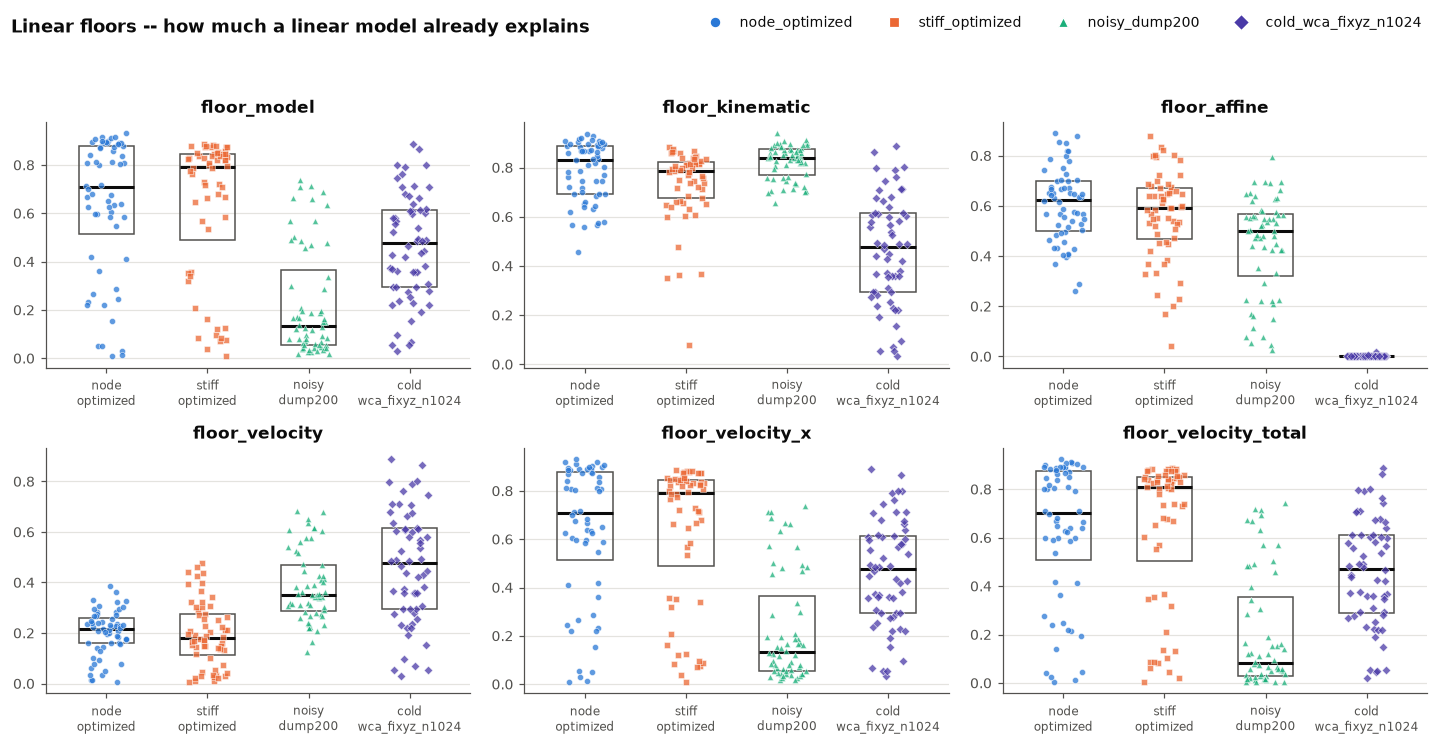

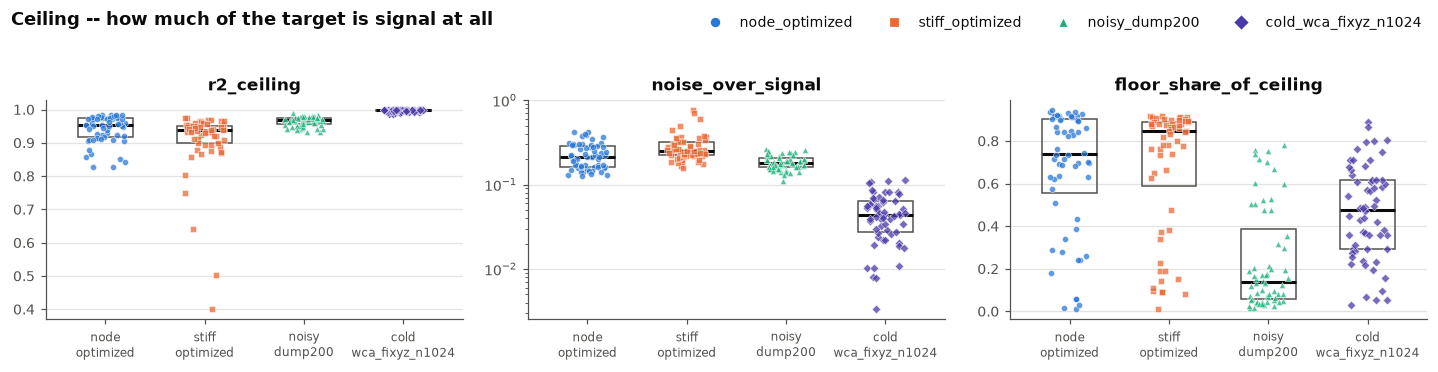

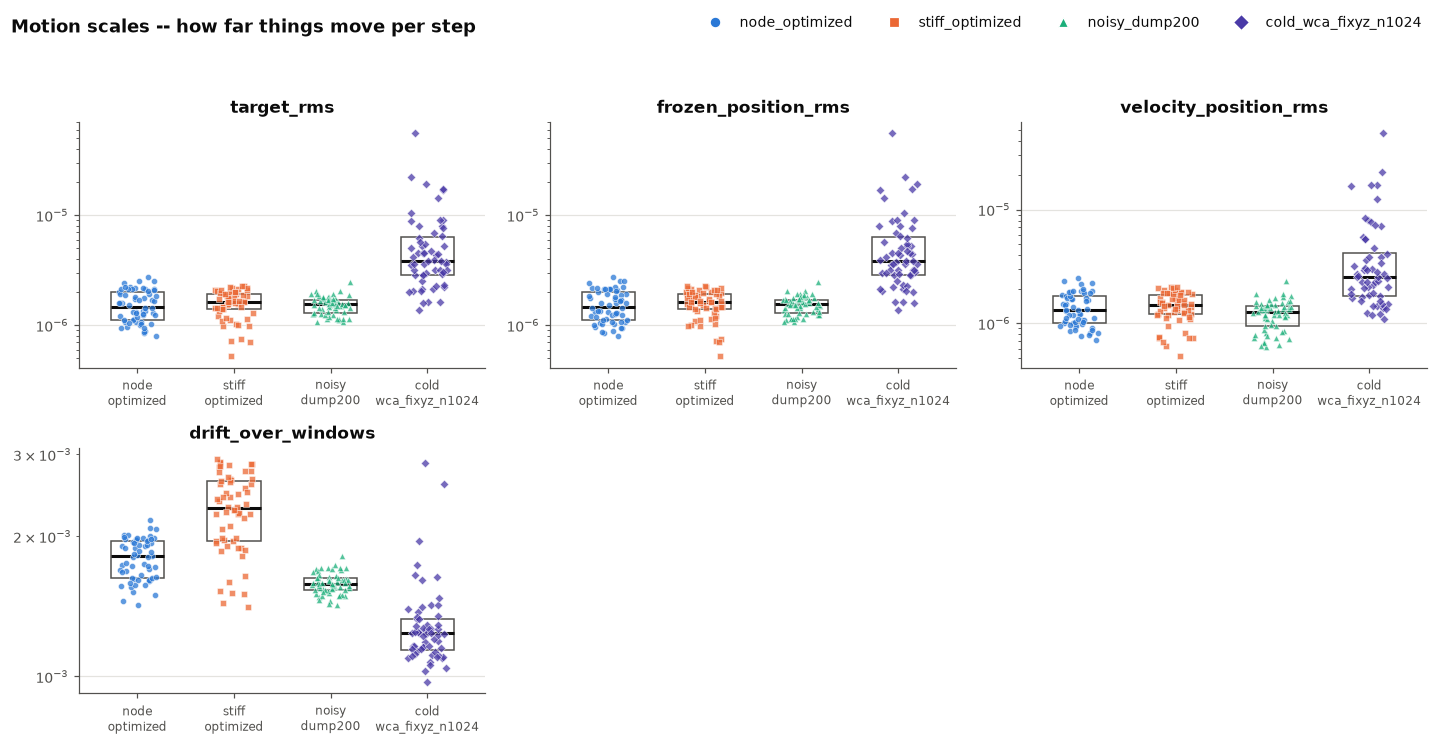

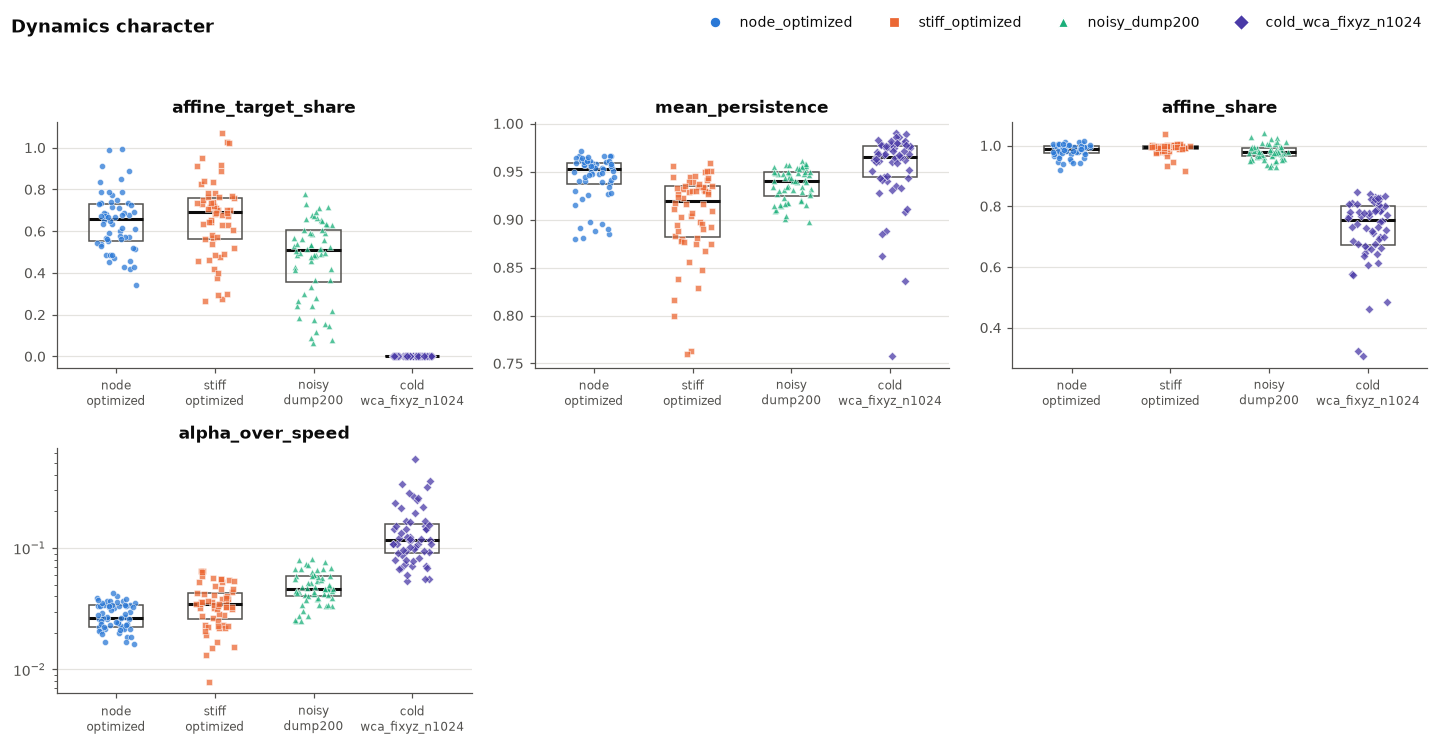

In [7]:
rng = np.random.default_rng(0)

def strip_panel(ax, metric):
    for i, key in enumerate(ORDER):
        values = rows.loc[rows.dataset == key, metric].dropna().to_numpy()
        if values.size == 0:
            continue
        ax.boxplot(values, positions=[i], widths=0.55, showfliers=False, whis=(0, 0),
                   showcaps=False, patch_artist=True,
                   boxprops=dict(facecolor="none", edgecolor=MUTED, linewidth=1),
                   medianprops=dict(color=INK, linewidth=2), whiskerprops=dict(linewidth=0))
        ax.scatter(i + rng.uniform(-0.2, 0.2, values.size), values, s=16, marker=MARKER[key],
                   color=COLOR[key], alpha=0.75, edgecolors="white", linewidths=0.4, zorder=3)
    ax.set_xticks(range(len(ORDER)), [k.replace("_", "\n", 1) for k in ORDER], fontsize=8)
    ax.set_xlim(-0.6, len(ORDER) - 0.4)
    ax.grid(axis="x", visible=False)
    if metric in LOG_SCALE:
        ax.set_yscale("log")
    ax.set_title(metric)

for group, metrics in GROUPS.items():
    names = list(metrics)
    columns = 3
    lines = -(-len(names) // columns)
    fig, axes = plt.subplots(lines, columns, figsize=(4.4 * columns, 3.4 * lines), squeeze=False)
    for ax, metric in zip(axes.flat, names):
        strip_panel(ax, metric)
    for ax in axes.flat[len(names):]:
        ax.set_visible(False)
    fig.suptitle(group, x=0.01, ha="left", fontsize=12, fontweight="bold")
    fig.legend(handles=legend_handles(), loc="upper right", ncol=len(ORDER), bbox_to_anchor=(0.99, 1.0))
    fig.tight_layout(rect=(0, 0, 1, 0.94))
    plt.show()

## Floor against ceiling

Systems close to the diagonal leave a model almost nothing to learn beyond the
linear floor; systems far below it are where a model can actually win. The
dashed line is `floor_model = r2_ceiling`.

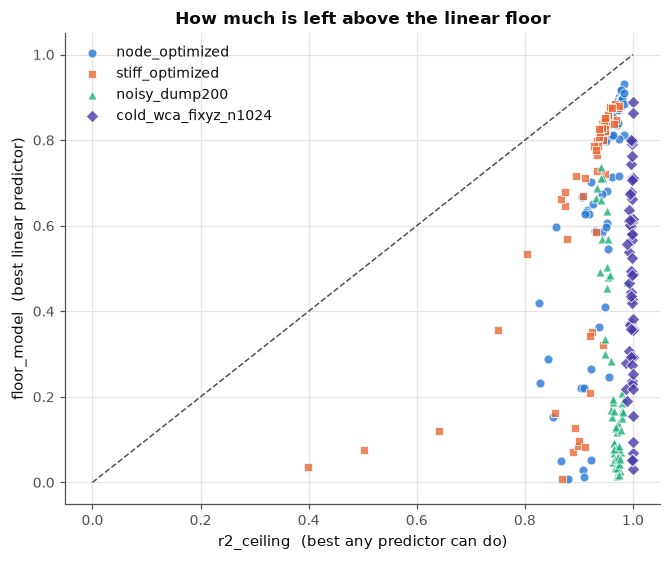

In [8]:
fig, ax = plt.subplots(figsize=(6.2, 5.2))
for key in ORDER:
    part = rows[rows.dataset == key]
    ax.scatter(part.r2_ceiling, part.floor_model, s=34, marker=MARKER[key], color=COLOR[key],
               alpha=0.8, edgecolors="white", linewidths=0.6, label=key)
low = min(rows.floor_model.min(), 0)
ax.plot([low, 1], [low, 1], ls="--", lw=1, color=MUTED)
ax.set_xlabel("r2_ceiling  (best any predictor can do)")
ax.set_ylabel("floor_model  (best linear predictor)")
ax.set_title("How much is left above the linear floor")
ax.legend(loc="upper left")
fig.tight_layout(); plt.show()

## What the floor tracks

The floor against how far a node moves in one step (the do-nothing error) and
against how straight its motion is (velocity persistence). High persistence
means the next velocity is mostly the last one, which a linear model gets for
free.

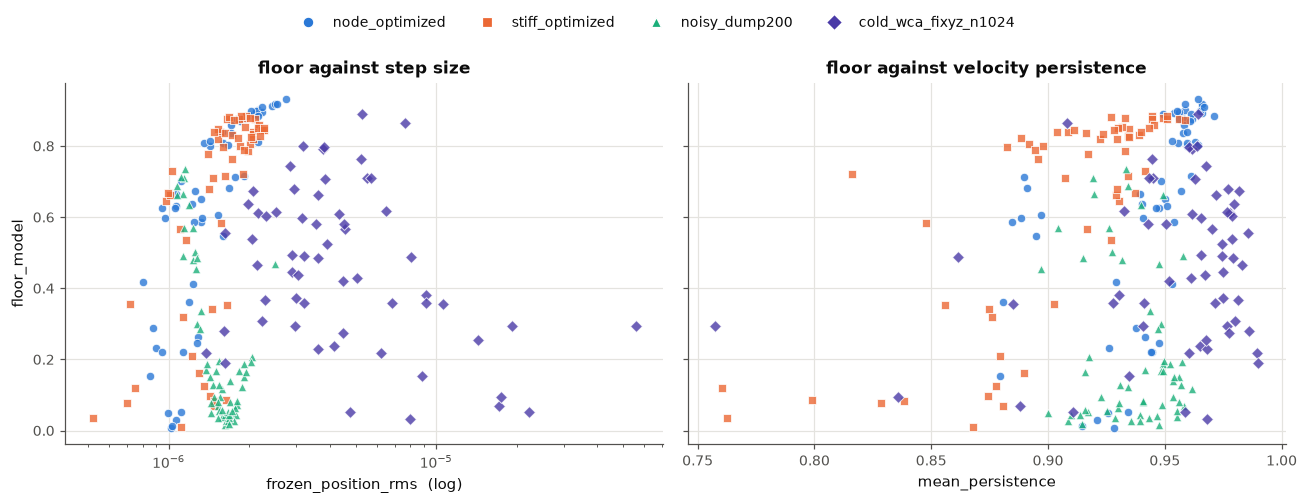

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), sharey=True)
for key in ORDER:
    part = rows[rows.dataset == key]
    style = dict(s=30, marker=MARKER[key], color=COLOR[key], alpha=0.8, edgecolors="white", linewidths=0.6, label=key)
    axes[0].scatter(part.frozen_position_rms, part.floor_model, **style)
    axes[1].scatter(part.mean_persistence, part.floor_model, **style)
axes[0].set_xscale("log")
axes[0].set_xlabel("frozen_position_rms  (log)")
axes[0].set_ylabel("floor_model")
axes[0].set_title("floor against step size")
axes[1].set_xlabel("mean_persistence")
axes[1].set_title("floor against velocity persistence")
fig.legend(handles=legend_handles(), loc="upper center", ncol=len(ORDER), bbox_to_anchor=(0.5, 1.0))
fig.tight_layout(rect=(0, 0, 1, 0.92)); plt.show()

## Within a dataset: stiff_optimized by family

`stiff_optimized` holds two generations of systems, `chunk_<n>` and
`chunk_highP_<n>`, which differ a lot in difficulty. Any dataset whose stems
fall into more than one `<prefix>_<n>` family is split the same way here.

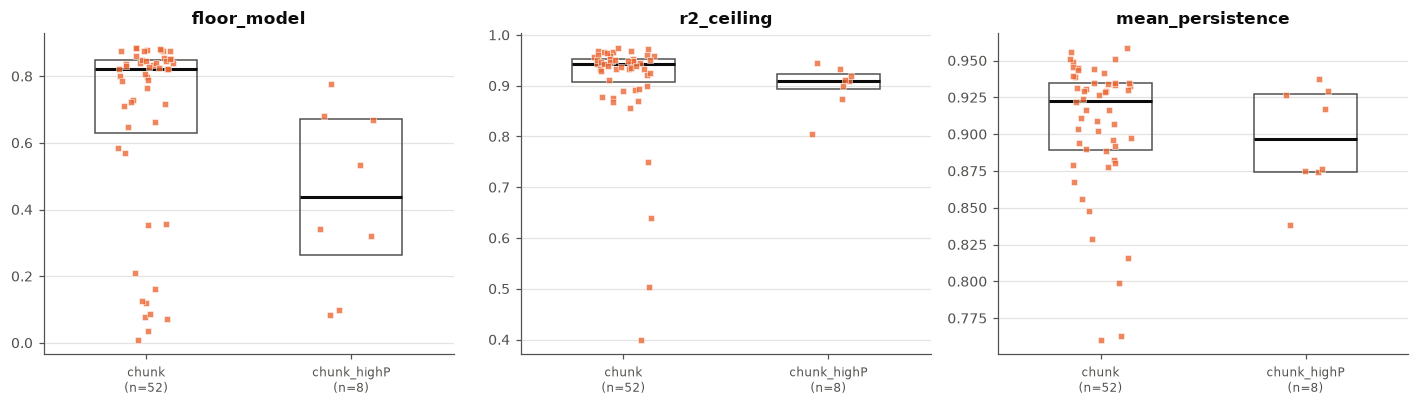

In [10]:
rows["family"] = rows.system.str.replace(r"_\d+$", "", regex=True)
families = rows.groupby("dataset", observed=True).family.nunique()
split = [key for key in ORDER if families.get(key, 1) > 1]
if not split:
    print("no measured dataset has more than one stem family.")
else:
    table = rows[rows.dataset.isin(split)].groupby(["dataset", "family"], observed=True)[HEADLINE].agg(["median", "size"])
    table = table.loc[:, (slice(None), "median")].droplevel(1, axis=1).join(
        rows[rows.dataset.isin(split)].groupby(["dataset", "family"], observed=True).size().rename("systems"))
    display(table.style.format("{:.3f}", subset=HEADLINE))

    fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
    for ax, metric in zip(axes, ["floor_model", "r2_ceiling", "mean_persistence"]):
        labels = []
        for i, (key, family) in enumerate(table.index):
            values = rows.loc[(rows.dataset == key) & (rows.family == family), metric].to_numpy()
            ax.boxplot(values, positions=[i], widths=0.5, showfliers=False, whis=(0, 0), showcaps=False,
                       patch_artist=True, boxprops=dict(facecolor="none", edgecolor=MUTED),
                       medianprops=dict(color=INK, linewidth=2), whiskerprops=dict(linewidth=0))
            ax.scatter(i + rng.uniform(-0.15, 0.15, values.size), values, s=18, marker=MARKER[key],
                       color=COLOR[key], alpha=0.8, edgecolors="white", linewidths=0.4, zorder=3)
            labels.append(f"{family}\n(n={values.size})")
        ax.set_xticks(range(len(labels)), labels, fontsize=8)
        ax.grid(axis="x", visible=False)
        ax.set_title(metric)
    fig.tight_layout(); plt.show()

## Optional: per-bond stiffness of the harmonic sets

This is what separates the 2D sets physically: whether the stiffness is `1/l0`,
`1/l0` with noise, or optimised and unrelated to the rest length. It **reads the
trajectory files** of the systems measured above, a few GB in all, so it is off
by default -- set `READ_TRAJECTORIES = True` to run it.

`k·l0` is exactly 1 when the stiffness is `1/l0`. A system whose `k·l0` has
(almost) zero spread follows *some* `c/l0` rule -- in `stiff_optimized` those
are the optimiser's unoptimised starting networks, at `c = 0.5`. The last column
is the share of bonds that sit exactly on `1/l0`.

In [11]:
READ_TRAJECTORIES = False

if READ_TRAJECTORIES:
    import torch
    from gnn_physics_benchmark.data import loading

    profile = []
    for key in ORDER:
        entry = registry.get(key)
        if (entry.potential or {}).get("kind") != "harmonic":
            continue
        columns = entry.schema.edge_columns
        for stem in rows.loc[rows.dataset == key, "system"]:
            edge_attr = loading.load_trajectory(entry, stem, max_frames=1)[0].edge_attr.double()
            k = edge_attr[:, columns.index("stiffness")]
            kl0 = k * edge_attr[:, columns.index("rest_length")]
            profile.append({"dataset": key, "system": stem, "kl0_mean": float(kl0.mean()),
                            "kl0_std": float(kl0.std()), "k_min": float(k.min()), "k_max": float(k.max()),
                            "kl0_values": kl0.numpy()})
    profile = pd.DataFrame(profile)
    profile["follows_c_over_l0"] = profile.kl0_std < 1e-4
    profile["on_1_over_l0"] = [float((np.abs(v - 1) < 1e-5).mean()) for v in profile.kl0_values]
    keys = list(dict.fromkeys(profile.dataset))

    display(profile.groupby("dataset", sort=False).agg(
        systems=("system", "size"), kl0_mean=("kl0_mean", "median"), kl0_spread=("kl0_std", "median"),
        k_min=("k_min", "min"), k_max=("k_max", "max"), follows_c_over_l0=("follows_c_over_l0", "sum"),
        share_of_bonds_on_1_over_l0=("on_1_over_l0", "median")))

    # One shared x axis: a set that is exactly 1/l0 must show as a single spike at 1,
    # not be auto-zoomed into its own float rounding.
    every = np.concatenate(profile.kl0_values.to_list())
    bins = np.linspace(0, max(1.1, every.max() * 1.02), 90)
    fig, axes = plt.subplots(1, len(keys), figsize=(4.4 * len(keys), 3.6), squeeze=False, sharex=True)
    for ax, key in zip(axes.flat, keys):
        values = np.concatenate(profile.loc[profile.dataset == key, "kl0_values"].to_list())
        ax.hist(values, bins=bins, color=COLOR[key], edgecolor="white", linewidth=0.3)
        ax.axvline(1.0, ls="--", lw=1, color=MUTED)
        ax.set_title(key)
        ax.set_xlabel("k · l0  (1 = the 1/l0 rule)")
        ax.set_yscale("log")
    axes.flat[0].set_ylabel("bonds")
    fig.tight_layout(); plt.show()
else:
    print("skipped: set READ_TRAJECTORIES = True to read the trajectory files.")

skipped: set READ_TRAJECTORIES = True to read the trajectory files.
